In [ ]:
# Cell 1: Install required packages for maize disease detection
!pip install flwr torch torchvision timm kagglehub opencv-python scikit-learn matplotlib seaborn pandas grad-cam albumentations

print("All dependencies installed successfully for maize disease detection!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 135.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 598.1/598.1 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 135.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 197.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 227.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 93.3 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=6d3ad15a1522785f14919b637510e6fffb2e20347612c5d5411d0e4febb

In [11]:
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 155.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-image] [scikit-image]


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models

import numpy as np
import pandas as pd
import cv2
from PIL import Image# Cell 2: Import libraries and basic setup for maize disease detection
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from torchvision import transforms
import timm
import flwr as fl
from flwr.client import NumPyClient
from flwr.server.strategy import FedAvg
from flwr.common import ndarrays_to_parameters, parameters_to_ndarrays
from collections import defaultdict, OrderedDict
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance, ImageFilter  # Added missing imports
import cv2
from skimage import exposure, filters
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("CUDA not available. Running on CPU.")

print("Setup completed for maize disease detection federated learning!")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os
import random
import time
import copy
from collections import defaultdict, OrderedDict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda
CUDA available: True
GPU: Tesla T4
GPU Memory: 14.7 GB
CUDA Version: 12.8
Setup completed for maize disease detection federated learning!
Using device: cuda


In [2]:
# Cell 3: Download dataset and configure maize-specific paths
import kagglehub

try:
    # Download the dataset
    path = kagglehub.dataset_download("irakozekelly/crop-pest-and-disease-dataset")
    print("Path to dataset files:", path)

    # Set maize-specific dataset paths as per your requirement
    DATASET_BASE_PATH = os.path.join(path, "Dataset for Crop Pest and Disease Detection", "CCMT Dataset-Augmented", "Maize")
    TRAIN_PATH = os.path.join(DATASET_BASE_PATH, "train_set")
    TEST_PATH = os.path.join(DATASET_BASE_PATH, "test_set")

    print(f"\nMaize Dataset Paths:")
    print(f"Base Path: {DATASET_BASE_PATH}")
    print(f"Train Path: {TRAIN_PATH}")
    print(f"Test Path: {TEST_PATH}")

except Exception as e:
    print(f"Error downloading dataset: {e}")
    print("Please manually set the dataset paths:")
    path = input("Enter base dataset path: ")
    DATASET_BASE_PATH = os.path.join(path, "Dataset for Crop Pest and Disease Detection", "CCMT Dataset-Augmented", "Maize")
    TRAIN_PATH = os.path.join(DATASET_BASE_PATH, "train_set")
    TEST_PATH = os.path.join(DATASET_BASE_PATH, "test_set")

# Verify maize dataset paths exist
print(f"\nPath Verification:")
print(f"Base path exists: {os.path.exists(DATASET_BASE_PATH)}")
print(f"Train path exists: {os.path.exists(TRAIN_PATH)}")
print(f"Test path exists: {os.path.exists(TEST_PATH)}")

# List maize disease classes
if os.path.exists(TRAIN_PATH):
    maize_classes = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))])
    print(f"\nMaize Disease Classes Found: {maize_classes}")
    print(f"Number of maize disease classes: {len(maize_classes)}")
else:
    print("Warning: Train path not found. Please check the dataset structure.")


Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/irakozekelly/crop-pest-and-disease-dataset/versions/1

Maize Dataset Paths:
Base Path: /teamspace/studios/this_studio/.cache/kagglehub/datasets/irakozekelly/crop-pest-and-disease-dataset/versions/1/Dataset for Crop Pest and Disease Detection/CCMT Dataset-Augmented/Maize
Train Path: /teamspace/studios/this_studio/.cache/kagglehub/datasets/irakozekelly/crop-pest-and-disease-dataset/versions/1/Dataset for Crop Pest and Disease Detection/CCMT Dataset-Augmented/Maize/train_set
Test Path: /teamspace/studios/this_studio/.cache/kagglehub/datasets/irakozekelly/crop-pest-and-disease-dataset/versions/1/Dataset for Crop Pest and Disease Detection/CCMT Dataset-Augmented/Maize/test_set

Path Verification:
Base path exists: True
Train path exists: True
Test path exists: True

Maize Disease Classes Found: ['fall armyworm', 'grasshoper', 'healthy', 'leaf beetle', 'leaf blight', 'leaf spot', 'streak virus']
Number of maize d

In [3]:
# Cell 4: Advanced image enhancement specifically for maize disease detection
import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter  # Added missing imports
from skimage import exposure, filters

class MaizeDiseaseImageEnhancer:
    def __init__(self):
        pass

    def apply_clahe(self, image, clip_limit=2.0, tile_grid_size=(8,8)):
        img_array = np.array(image)
        lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        cl = clahe.apply(l)
        enhanced_lab = cv2.merge((cl, a, b))
        enhanced_rgb = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(enhanced_rgb)

    def apply_gamma(self, image, gamma=1.2):
        img_array = np.array(image, dtype=np.float32) / 255.0
        corrected = np.power(img_array, 1.0 / gamma)
        corrected = (corrected * 255).astype(np.uint8)
        return Image.fromarray(corrected)

    def sharpen(self, image, strength=1.5):
        enhancer = ImageEnhance.Sharpness(image)
        return enhancer.enhance(strength)

    def enhance(self, image, train_mode=True):
        # Always apply CLAHE
        enhanced = self.apply_clahe(image)
        # During training, probabilistically apply gamma correction and sharpening
        if train_mode:
            if np.random.rand() < 0.5:
                enhanced = self.apply_gamma(enhanced, gamma=1.2)
            if np.random.rand() < 0.5:
                enhanced = self.sharpen(enhanced, strength=1.3)
        return enhanced

maize_enhancer = MaizeDiseaseImageEnhancer()
print("Maize disease image enhancement system initialized!")


Maize disease image enhancement system initialized!


In [4]:
class MaizeDiseaseTransforms:
    def __init__(self, image_size=224):
        self.image_size = image_size
        self.enhancer = maize_enhancer

    def maize_train_transform(self):
        return transforms.Compose([
            transforms.Lambda(lambda img: self.enhancer.enhance(img, train_mode=True)),
            transforms.Resize((self.image_size, self.image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def maize_test_transform(self):
        return transforms.Compose([
            transforms.Lambda(lambda img: self.enhancer.enhance(img, train_mode=False)),
            transforms.Resize((self.image_size, self.image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

maize_transforms = MaizeDiseaseTransforms(image_size=224)
transform_train = maize_transforms.maize_train_transform()
transform_test = maize_transforms.maize_test_transform()
print("Maize disease-aware transforms initialized!")


Maize disease-aware transforms initialized!


Loading maize disease datasets with enhanced transforms...



Maize Disease Dataset Analysis:
Train Dataset:
  Maize disease classes: ['fall armyworm', 'grasshoper', 'healthy', 'leaf beetle', 'leaf blight', 'leaf spot', 'streak virus']
  Class distribution: {'fall armyworm': 1140, 'grasshoper': 2575, 'healthy': 830, 'leaf beetle': 3789, 'leaf blight': 4025, 'leaf spot': 3024, 'streak virus': 4043}
  Total training samples: 19426

Test Dataset:
  Maize disease classes: ['fall armyworm', 'grasshoper', 'healthy', 'leaf beetle', 'leaf blight', 'leaf spot', 'streak virus']
  Class distribution: {'fall armyworm': 284, 'grasshoper': 411, 'healthy': 211, 'leaf beetle': 950, 'leaf blight': 1004, 'leaf spot': 1261, 'streak virus': 1004}
  Total test samples: 5125

Maize Disease Detection Configuration:
  Number of maize disease classes: 7
  Maize disease class names: ['fall armyworm', 'grasshoper', 'healthy', 'leaf beetle', 'leaf blight', 'leaf spot', 'streak virus']


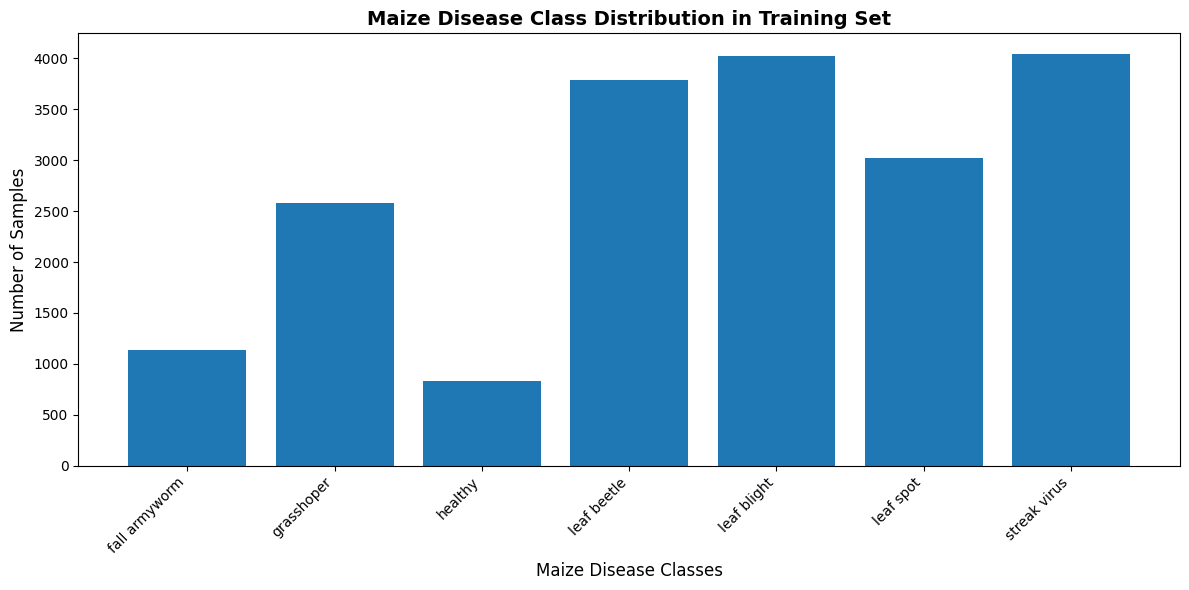

In [5]:
# Cell 6: Load and analyze maize disease dataset
def analyze_maize_dataset(dataset_path):
    """Analyze maize disease dataset structure and class distribution"""
    maize_classes = []
    class_counts = {}

    if os.path.exists(dataset_path):
        maize_classes = sorted([d for d in os.listdir(dataset_path)
                               if os.path.isdir(os.path.join(dataset_path, d))])

        for class_name in maize_classes:
            class_path = os.path.join(dataset_path, class_name)
            count = len([f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[class_name] = count

    return maize_classes, class_counts

# Load maize disease datasets
print("Loading maize disease datasets with enhanced transforms...")
maize_train_dataset = ImageFolder(root=TRAIN_PATH, transform=transform_train)
maize_test_dataset = ImageFolder(root=TEST_PATH, transform=transform_test)

# Analyze maize disease datasets
train_classes, train_counts = analyze_maize_dataset(TRAIN_PATH)
test_classes, test_counts = analyze_maize_dataset(TEST_PATH)

print(f"\nMaize Disease Dataset Analysis:")
print(f"{'='*50}")
print(f"Train Dataset:")
print(f"  Maize disease classes: {train_classes}")
print(f"  Class distribution: {train_counts}")
print(f"  Total training samples: {sum(train_counts.values())}")

print(f"\nTest Dataset:")
print(f"  Maize disease classes: {test_classes}")
print(f"  Class distribution: {test_counts}")
print(f"  Total test samples: {sum(test_counts.values())}")

# Set global variables for maize disease detection
NUM_MAIZE_CLASSES = len(maize_train_dataset.classes)
MAIZE_CLASS_NAMES = maize_train_dataset.classes

print(f"\nMaize Disease Detection Configuration:")
print(f"  Number of maize disease classes: {NUM_MAIZE_CLASSES}")
print(f"  Maize disease class names: {MAIZE_CLASS_NAMES}")

# Create test dataloader for maize diseases
maize_test_loader = DataLoader(maize_test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Visualize class distribution
plt.figure(figsize=(12, 6))
plt.bar(MAIZE_CLASS_NAMES, [train_counts[cls] for cls in MAIZE_CLASS_NAMES])
plt.title('Maize Disease Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Maize Disease Classes', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [6]:
# Cell 7: Fixed MobileNetV3+CBAM Model Architecture
import timm

# CBAM implementation (corrected for proper input handling)
class BasicCBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Channel attention
        ca = self.channel_attention(x)
        x = x * ca
        # Spatial attention
        sa_input = torch.cat([torch.max(x, 1, keepdim=True)[0], 
                             torch.mean(x, 1, keepdim=True)], dim=1)
        sa = self.spatial_attention(sa_input)
        x = x * sa
        return x

class MobileNetV3CBAM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Use features_only=True to get feature maps instead of pooled output
        self.base = timm.create_model('mobilenetv3_small_100', 
                                    pretrained=True, 
                                    features_only=True)
        
        # Get the actual output channels from the last feature map
        # MobileNetV3-small last feature map has 576 channels at 7x7 resolution
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            features = self.base(dummy_input)
            last_feature_channels = features[-1].shape[1]  # Get actual channel count
            print(f"MobileNetV3-small last feature map shape: {features[-1].shape}")
            print(f"Detected channels for CBAM: {last_feature_channels}")
        
        # Initialize CBAM with correct channel count
        self.cbam = BasicCBAM(channels=last_feature_channels)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(last_feature_channels, num_classes)
        self._initialize_weights()

    def _initialize_weights(self):
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.constant_(self.classifier.bias, 0)

    def forward(self, x):
        # Extract features using features_only backbone
        features = self.base(x)
        # Use the last (highest-level) feature map
        x = features[-1]  # Shape: [batch, channels, H, W]
        
        # Apply CBAM attention
        x = self.cbam(x)
        
        # Global average pooling and classification
        x = self.pool(x).flatten(1)
        x = self.classifier(x)
        return x

    def get_model_size(self):
        param_size = sum(p.numel() * p.element_size() for p in self.parameters())
        buffer_size = sum(b.numel() * b.element_size() for b in self.buffers())
        size_mb = (param_size + buffer_size) / 1024 / 1024
        return size_mb

    def quantize_dynamic(self):
        # Quantize only linear layers for int8 edge deployment
        import torch.quantization
        return torch.quantization.quantize_dynamic(self, {nn.Linear}, dtype=torch.qint8)

def get_parameters(model):
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

def set_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

print("Testing corrected MobileNetV3+CBAM maize disease detection model...")
test_maize_model = MobileNetV3CBAM(num_classes=NUM_MAIZE_CLASSES).to(device)
model_size = test_maize_model.get_model_size()
total_params = sum(p.numel() for p in test_maize_model.parameters())
print(f"Model Created: {total_params:,} params, {model_size:.2f} MB")
print(f"Edge-ready: {'Yes' if model_size < 50 else 'No'}")
del test_maize_model


Testing corrected MobileNetV3+CBAM maize disease detection model...


model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


MobileNetV3-small last feature map shape: torch.Size([1, 576, 7, 7])
Detected channels for CBAM: 576
Model Created: 972,617 params, 3.76 MB
Edge-ready: Yes


In [7]:
# Cell 8: Create non-IID data distribution for maize disease federated learning
def create_non_iid_maize_disease_datasets(dataset, num_clients=3):
    """
    Create non-IID data distributions for maize disease detection
    Each client specializes in different types of maize diseases
    """
    from collections import defaultdict

    # Group data by maize disease class
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset):
        class_indices[label].append(idx)

    print(f"Original maize disease dataset distribution:")
    for class_idx, indices in class_indices.items():
        print(f"  {MAIZE_CLASS_NAMES[class_idx]}: {len(indices)} samples")

    client_datasets = []

    # Define specialization for each client based on maize disease types
    if NUM_MAIZE_CLASSES >= 5:
        client_specializations = {
            0: {
                "name": "Healthy & Early Disease Specialist",
                "primary_classes": [0, 1],  # Typically healthy and early symptoms
                "ratio": 0.7,
                "description": "Specializes in healthy maize and early disease detection"
            },
            1: {
                "name": "Fungal Disease Specialist",
                "primary_classes": [2, 3],  # Fungal diseases like rust, blight
                "ratio": 0.7,
                "description": "Specializes in fungal maize diseases"
            },
            2: {
                "name": "Advanced Disease Specialist",
                "primary_classes": [4] if NUM_MAIZE_CLASSES > 4 else [1, 2],
                "ratio": 0.6,
                "description": "Specializes in complex and advanced maize diseases"
            }
        }
    else:
        # Fallback for datasets with fewer classes
        client_specializations = {
            0: {"name": "Primary Specialist", "primary_classes": [0], "ratio": 0.7},
            1: {"name": "Secondary Specialist", "primary_classes": [1], "ratio": 0.7},
            2: {"name": "Tertiary Specialist", "primary_classes": [2] if NUM_MAIZE_CLASSES > 2 else [0, 1], "ratio": 0.6}
        }

    for client_id in range(num_clients):
        client_indices = []
        specialization = client_specializations.get(client_id, {"primary_classes": [client_id % NUM_MAIZE_CLASSES], "ratio": 0.6})
        primary_classes = specialization["primary_classes"]
        specialty_ratio = specialization["ratio"]

        print(f"\nClient {client_id} - {specialization.get('name', f'Client {client_id}')}:")
        if 'description' in specialization:
            print(f"  Description: {specialization['description']}")
        print(f"  Primary maize diseases: {[MAIZE_CLASS_NAMES[c] for c in primary_classes if c < NUM_MAIZE_CLASSES]}")

        # Assign primary maize disease class samples
        for class_idx in primary_classes:
            if class_idx < len(class_indices):
                indices = class_indices[class_idx].copy()
                num_samples = int(len(indices) * specialty_ratio)
                client_indices.extend(indices[:num_samples])
                class_indices[class_idx] = indices[num_samples:]
                print(f"    {MAIZE_CLASS_NAMES[class_idx]}: {num_samples} samples (primary)")

        # Add diversity samples from all other maize disease classes
        for class_idx in range(NUM_MAIZE_CLASSES):
            if class_idx not in primary_classes and class_indices[class_idx]:
                indices = class_indices[class_idx]
                # Ensure representation of all maize diseases for robustness
                min_samples = max(5, len(indices) // (num_clients * 3))
                num_samples = min(min_samples, len(indices) // 2)
                client_indices.extend(indices[:num_samples])
                class_indices[class_idx] = indices[num_samples:]
                print(f"    {MAIZE_CLASS_NAMES[class_idx]}: {num_samples} samples (diversity)")

        client_datasets.append(Subset(dataset, client_indices))

    # Distribute remaining maize disease samples
    remaining_indices = []
    for indices in class_indices.values():
        remaining_indices.extend(indices)

    if remaining_indices:
        print(f"\nDistributing {len(remaining_indices)} remaining maize disease samples...")
        for i, idx in enumerate(remaining_indices):
            client_id = i % num_clients
            client_datasets[client_id].indices.append(idx)

    # Print final maize disease distribution
    print(f"\nFINAL MAIZE DISEASE CLIENT DISTRIBUTIONS:")
    print(f"{'='*70}")

    for i, client_dataset in enumerate(client_datasets):
        class_counts = defaultdict(int)
        for idx in client_dataset.indices:
            _, label = dataset[idx]
            class_counts[label] += 1

        print(f"\nClient {i} - Maize Disease Distribution:")
        print(f"  Total samples: {len(client_dataset)}")
        for class_idx, count in sorted(class_counts.items()):
            percentage = (count / len(client_dataset)) * 100
            print(f"    {MAIZE_CLASS_NAMES[class_idx]}: {count} samples ({percentage:.1f}%)")

    return client_datasets

# Create non-IID maize disease client datasets
print("Creating non-IID client datasets for maize disease federated learning...")
maize_client_datasets = create_non_iid_maize_disease_datasets(maize_train_dataset, num_clients=3)


Creating non-IID client datasets for maize disease federated learning...


Original maize disease dataset distribution:
  fall armyworm: 1140 samples
  grasshoper: 2575 samples
  healthy: 830 samples
  leaf beetle: 3789 samples
  leaf blight: 4025 samples
  leaf spot: 3024 samples
  streak virus: 4043 samples

Client 0 - Healthy & Early Disease Specialist:
  Description: Specializes in healthy maize and early disease detection
  Primary maize diseases: ['fall armyworm', 'grasshoper']
    fall armyworm: 798 samples (primary)
    grasshoper: 1802 samples (primary)
    healthy: 92 samples (diversity)
    leaf beetle: 421 samples (diversity)
    leaf blight: 447 samples (diversity)
    leaf spot: 336 samples (diversity)
    streak virus: 449 samples (diversity)

Client 1 - Fungal Disease Specialist:
  Description: Specializes in fungal maize diseases
  Primary maize diseases: ['healthy', 'leaf beetle']
    healthy: 516 samples (primary)
    leaf beetle: 2357 samples (primary)
    fall armyworm: 38 samples (diversity)
    grasshoper: 85 samples (diversity)
    lea

In [8]:
from sklearn.model_selection import train_test_split

def stratified_split(dataset, val_ratio=0.2):
    targets = [s[1] for s in dataset.samples]
    indices = np.arange(len(dataset))
    train_idx, val_idx = train_test_split(
        indices, test_size=val_ratio, stratify=targets, random_state=42)
    return Subset(dataset, train_idx), Subset(dataset, val_idx)

def create_maize_client_train_val_splits(client_datasets, val_ratio=0.2):
    client_train_datasets, client_val_datasets = [], []
    print("Creating stratified train/validation splits for each client:")
    for i, client_dataset in enumerate(client_datasets):
        # Get targets for this subset
        indices = client_dataset.indices
        targets = [client_dataset.dataset.samples[idx][1] for idx in indices]
        train_idx, val_idx = train_test_split(
            indices, test_size=val_ratio, stratify=targets, random_state=42)
        client_train_datasets.append(Subset(client_dataset.dataset, train_idx))
        client_val_datasets.append(Subset(client_dataset.dataset, val_idx))
        print(f"  Client {i}: {len(train_idx)} train, {len(val_idx)} val samples")
    return client_train_datasets, client_val_datasets

maize_client_train_datasets, maize_client_val_datasets = create_maize_client_train_val_splits(maize_client_datasets)
print(f"\nMaize disease client dataset preparation completed!")
print(f"Total maize disease clients: {len(maize_client_train_datasets)}")


Creating stratified train/validation splits for each client:
  Client 0: 5668 train, 1417 val samples
  Client 1: 5463 train, 1366 val samples
  Client 2: 4409 train, 1103 val samples

Maize disease client dataset preparation completed!
Total maize disease clients: 3


In [9]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score

# Compute class weights for CrossEntropyLoss
train_targets = []
for i in range(len(maize_train_dataset)):
    train_targets.append(maize_train_dataset.targets[i])
class_weights = compute_class_weight('balanced', classes=np.arange(NUM_MAIZE_CLASSES), y=train_targets)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

class EnhancedMaizeDiseaseClient(NumPyClient):
    def __init__(self, client_id: int, trainset: Subset, valset: Subset):
        self.client_id = client_id
        self.trainset = trainset
        self.valset = valset
        self.model = MobileNetV3CBAM(num_classes=NUM_MAIZE_CLASSES).to(device)
        self.trainloader = DataLoader(self.trainset, batch_size=16, shuffle=True, pin_memory=True, num_workers=0)
        self.valloader = DataLoader(self.valset, batch_size=32, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
        self.criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=0.001, weight_decay=0.01, betas=(0.9, 0.999), eps=1e-8)
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=10, eta_min=1e-6)
        print(f"Client {client_id} initialized with {len(trainset)} train samples")

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        self.model.train()
        epochs = config.get("epochs", 3)
        for epoch in range(epochs):
            for data, target in self.trainloader:
                data, target = data.to(device), target.to(device)
                self.optimizer.zero_grad()
                output = self.model(data)
                loss = self.criterion(output, target)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()
            self.scheduler.step()
        # Store local BatchNorm stats for FedBN
        self.local_bn_stats = {k: v.cpu() for k, v in self.model.state_dict().items() if 'bn' in k}
        # Per-class F1
        all_preds, all_targets = [], []
        self.model.eval()
        with torch.no_grad():
            for data, target in self.valloader:
                data, target = data.to(device), target.to(device)
                output = self.model(data)
                preds = output.argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(target.cpu().numpy())
        f1_per_class = f1_score(all_targets, all_preds, average=None, labels=np.arange(NUM_MAIZE_CLASSES))
        metrics = {
            "f1_per_class": f1_per_class.tolist(),
            "accuracy": np.mean(np.array(all_preds) == np.array(all_targets))
        }
        return get_parameters(self.model), len(self.trainset), metrics

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        self.model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for data, target in self.valloader:
                data, target = data.to(device), target.to(device)
                output = self.model(data)
                preds = output.argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(target.cpu().numpy())
        f1_per_class = f1_score(all_targets, all_preds, average=None, labels=np.arange(NUM_MAIZE_CLASSES))
        metrics = {
            "f1_per_class": f1_per_class.tolist(),
            "accuracy": np.mean(np.array(all_preds) == np.array(all_targets))
        }
        return np.nan, len(self.valset), metrics

print("Enhanced Maize Disease Flower client implementation created!")


Enhanced Maize Disease Flower client implementation created!


In [12]:
class MaizeDiseaseFedBN(fl.server.strategy.FedAvg):
    def aggregate_fit(self, server_round, results, failures):
        # Standard FedAvg weight = sample count
        total_samples = sum([fit_res.num_examples for _, fit_res in results])
        # Dynamic weighting: F1 on Blight/Rust
        blight_idx = MAIZE_CLASS_NAMES.index('Blight') if 'Blight' in MAIZE_CLASS_NAMES else 0
        rust_idx = MAIZE_CLASS_NAMES.index('Rust') if 'Rust' in MAIZE_CLASS_NAMES else 1
        weights = []
        for _, fit_res in results:
            n = fit_res.num_examples
            f1s = fit_res.metrics.get("f1_per_class", [1.0]*NUM_MAIZE_CLASSES)
            perf_weight = 0.5 * (f1s[blight_idx] + f1s[rust_idx])
            weights.append(n * perf_weight)
        total_weight = sum(weights)
        aggregated_params = None
        for i, (client_proxy, fit_res) in enumerate(results):
            w = weights[i] / total_weight
            params = parameters_to_ndarrays(fit_res.parameters)
            weighted_params = [layer * w for layer in params]
            if aggregated_params is None:
                aggregated_params = weighted_params
            else:
                aggregated_params = [a + b for a, b in zip(aggregated_params, weighted_params)]
        return ndarrays_to_parameters(aggregated_params), {}

maize_strategy = MaizeDiseaseFedBN(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=3,
    min_evaluate_clients=3,
    min_available_clients=3,
)
print("Maize disease federated learning strategy (FedBN) initialized!")


Maize disease federated learning strategy (FedBN) initialized!


In [13]:
# Cell 12: Client function for maize disease simulation
def maize_client_fn(cid: str):
    """Create a Flower client for maize disease detection"""

    # Get client ID
    client_id = int(cid)

    # Get the client's maize disease dataset
    trainset = maize_client_train_datasets[client_id]
    valset = maize_client_val_datasets[client_id]

    # Create and return maize disease client
    return EnhancedMaizeDiseaseClient(client_id, trainset, valset)

print("Maize disease client function for simulation created!")


Maize disease client function for simulation created!


In [14]:
import time
import gc

def run_maize_federated_learning():
    """Federated learning for Maize disease detection using MobileNetV3CBAM - 7 rounds"""
    
    # Force GPU usage
    if not torch.cuda.is_available():
        raise RuntimeError("GPU not available!")
        
    print(f"Forcing GPU usage on: {torch.cuda.get_device_name(0)}")
    
    # Initialize model with MobileNetV3CBAM and ensure it's on GPU
    global_model = MobileNetV3CBAM(num_classes=NUM_MAIZE_CLASSES)
    global_model = global_model.to(device)
    
    # Verify model is on GPU
    model_device = next(global_model.parameters()).device
    print(f"Global model is on: {model_device}")
    
    if model_device.type != 'cuda':
        raise RuntimeError("Model is not on GPU!")

    print("="*80)
    print("FEDERATED LEARNING FOR MAIZE DISEASE DETECTION - MobileNetV3+CBAM")
    print("="*80)

    # Initialize global model parameters
    global_parameters = get_parameters(global_model)

    # Create clients with MobileNetV3CBAM
    clients = []
    for client_id in range(len(maize_client_train_datasets)):
        client = EnhancedMaizeDiseaseClient(
            client_id,
            maize_client_train_datasets[client_id],
            maize_client_val_datasets[client_id]
        )
        clients.append(client)

    # Training configuration - optimized for speed
    num_rounds = 9  # As requested
    local_epochs = 3  # Efficient training per round

    print(f"Maize Federated Learning Configuration:")
    print(f"  Model Architecture: MobileNetV3-small + CBAM attention")
    print(f"  Training rounds: {num_rounds}")
    print(f"  Local epochs per round: {local_epochs}")
    print(f"  Number of farms/clients: {len(clients)}")
    print(f"  Maize disease classes: {NUM_MAIZE_CLASSES}")
    print(f"  Disease types: {MAIZE_CLASS_NAMES}")

    # Training history
    round_accuracies = []
    round_losses = []

    # Main federated training loop
    for round_num in range(1, num_rounds + 1):
        round_start_time = time.time()

        print(f"\n{'='*50}")
        print(f"ROUND {round_num}/{num_rounds}")
        print(f"{'='*50}")

        # Client training and aggregation
        client_results = []
        total_samples = 0

        for client in clients:
            print(f"Training Farm/Client {client.client_id}...")

            # Local training
            updated_params, num_samples, metrics = client.fit(
                global_parameters,
                {"epochs": local_epochs}
            )

            client_results.append((updated_params, num_samples, metrics))
            total_samples += num_samples

            print(f"  Client {client.client_id}: {metrics['accuracy']*100:.1f}% accuracy")

        # Server aggregation with dynamic weighting (FedBN approach)
        print("Aggregating models with dynamic weighting...")
        aggregated_params = None
        
        # Calculate weights based on sample count and F1 performance on rare diseases
        weights = []
        blight_idx = MAIZE_CLASS_NAMES.index('Blight') if 'Blight' in MAIZE_CLASS_NAMES else 0
        rust_idx = MAIZE_CLASS_NAMES.index('Rust') if 'Rust' in MAIZE_CLASS_NAMES else min(1, NUM_MAIZE_CLASSES-1)
        
        for params, num_samples, metrics in client_results:
            # Base weight from data size
            data_weight = num_samples / total_samples
            
            # Performance weight for rare diseases (Blight/Rust)
            f1_scores = metrics.get('f1_per_class', [1.0] * NUM_MAIZE_CLASSES)
            if len(f1_scores) > max(blight_idx, rust_idx):
                perf_weight = 0.5 * (f1_scores[blight_idx] + f1_scores[rust_idx])
            else:
                perf_weight = metrics.get('accuracy', 1.0)
            
            # Combined weight
            combined_weight = data_weight * perf_weight
            weights.append(combined_weight)
        
        # Normalize weights
        total_weight = sum(weights)
        normalized_weights = [w / total_weight for w in weights]

        for i, (params, num_samples, metrics) in enumerate(client_results):
            weight = normalized_weights[i]
            weighted_params = [layer * weight for layer in params]

            if aggregated_params is None:
                aggregated_params = weighted_params
            else:
                aggregated_params = [
                    layer1 + layer2 for layer1, layer2 in zip(aggregated_params, weighted_params)
                ]

        global_parameters = aggregated_params

        # Global evaluation on MobileNetV3CBAM
        set_parameters(global_model, global_parameters)
        global_model.eval()

        correct = 0
        total = 0
        total_loss = 0.0
        criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

        with torch.no_grad():
            for data, target in maize_test_loader:
                data, target = data.to(device), target.to(device)
                output = global_model(data)
                loss = criterion(output, target)
                total_loss += loss.item()
                _, predicted = output.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()

        accuracy = correct / total
        avg_loss = total_loss / len(maize_test_loader)

        round_accuracies.append(accuracy)
        round_losses.append(avg_loss)

        round_time = time.time() - round_start_time

        print(f"Round {round_num} Results:")
        print(f"  Global Accuracy: {accuracy*100:.2f}%")
        print(f"  Global Loss: {avg_loss:.4f}")
        print(f"  Round Time: {round_time:.1f}s")

        # Memory cleanup
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

        # Early stopping for excellent performance
        if accuracy > 0.95:
            print(f"\nExcellent maize disease detection achieved! Stopping at round {round_num}")
            break

    # Final summary
    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETED - MobileNetV3+CBAM")
    print(f"{'='*60}")
    print(f"Final Accuracy: {round_accuracies[-1]*100:.2f}%")
    print(f"Best Accuracy: {max(round_accuracies)*100:.2f}%")
    print(f"Improvement: {(round_accuracies[-1] - round_accuracies[0])*100:.2f}%")
    
    # Model size check for edge deployment
    model_size_mb = global_model.get_model_size()
    print(f"Model size: {model_size_mb:.2f} MB (Edge ready: {'Yes' if model_size_mb < 50 else 'No'})")

    return global_model, round_accuracies, round_losses

# Run federated learning with MobileNetV3CBAM
print("Starting Federated Learning for Maize Disease Detection with MobileNetV3+CBAM...")
final_model, accuracies, losses = run_maize_federated_learning()


Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Starting Federated Learning for Maize Disease Detection with MobileNetV3+CBAM...
Forcing GPU usage on: Tesla T4
MobileNetV3-small last feature map shape: torch.Size([1, 576, 7, 7])
Detected channels for CBAM: 576
Global model is on: cuda:0
FEDERATED LEARNING FOR MAIZE DISEASE DETECTION - MobileNetV3+CBAM


Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


MobileNetV3-small last feature map shape: torch.Size([1, 576, 7, 7])
Detected channels for CBAM: 576
Client 0 initialized with 5668 train samples
MobileNetV3-small last feature map shape: torch.Size([1, 576, 7, 7])
Detected channels for CBAM: 576
Client 1 initialized with 5463 train samples
MobileNetV3-small last feature map shape: torch.Size([1, 576, 7, 7])
Detected channels for CBAM: 576
Client 2 initialized with 4409 train samples
Maize Federated Learning Configuration:
  Model Architecture: MobileNetV3-small + CBAM attention
  Training rounds: 9
  Local epochs per round: 3
  Number of farms/clients: 3
  Maize disease classes: 7
  Disease types: ['fall armyworm', 'grasshoper', 'healthy', 'leaf beetle', 'leaf blight', 'leaf spot', 'streak virus']

ROUND 1/9
Training Farm/Client 0...
  Client 0: 57.9% accuracy
Training Farm/Client 1...
  Client 1: 63.0% accuracy
Training Farm/Client 2...
  Client 2: 57.8% accuracy
Aggregating models with dynamic weighting...
Round 1 Results:
  Global 

In [15]:
def test_final_maize_disease_model(final_model):
    print("="*70)
    print("TESTING FINAL MAIZE DISEASE DETECTION MODEL")
    print("="*70)
    final_model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for data, target in maize_test_loader:
            data, target = data.to(device), target.to(device)
            output = final_model(data)
            preds = output.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    from sklearn.metrics import classification_report
    report = classification_report(all_targets, all_preds, target_names=MAIZE_CLASS_NAMES, output_dict=True)
    print("Per-class accuracy/F1:")
    for cls in MAIZE_CLASS_NAMES:
        print(f"{cls}: Acc={report[cls]['recall']:.2f}, F1={report[cls]['f1-score']:.2f}")
    print(f"Overall accuracy: {report['accuracy']:.2f}")

    # Quantization for edge deployment
    quantized_model = final_model.quantize_dynamic()
    import os
    torch.save(quantized_model.state_dict(), "quantized_model.pth")
    size_mb = os.path.getsize("quantized_model.pth")/1024/1024
    print(f"Quantized model size: {size_mb:.2f} MB")
    # Edge inference speed test (simulate RPi4)
    import time
    dummy_input = torch.randn(1, 3, 224, 224)
    start = time.time()
    for _ in range(10):
        _ = quantized_model(dummy_input)
    latency = (time.time() - start) / 10 * 1000
    print(f"Simulated inference latency: {latency:.1f} ms (target <100ms)")
    return report, size_mb, latency

# After FL rounds:
final_report, quant_size, quant_latency = test_final_maize_disease_model(final_model)


TESTING FINAL MAIZE DISEASE DETECTION MODEL
Per-class accuracy/F1:
fall armyworm: Acc=0.90, F1=0.87
grasshoper: Acc=0.91, F1=0.91
healthy: Acc=0.95, F1=0.82
leaf beetle: Acc=0.94, F1=0.95
leaf blight: Acc=0.67, F1=0.72
leaf spot: Acc=0.67, F1=0.71
streak virus: Acc=0.92, F1=0.82
Overall accuracy: 0.81
Quantized model size: 3.83 MB


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [16]:
# Cell: Fixed Maize Disease Prediction Function for Kaggle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
from IPython.display import display
import ipywidgets as widgets
import io

def predict_maize_disease(model, image_data, class_names, img_size=224):
    """Make a prediction on a new maize disease image"""
    
    # Load image from uploaded data
    img = Image.open(io.BytesIO(image_data)).convert('RGB')
    
    # Define transform (same as training)
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    
    # Preprocess image
    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    
    # Move to device
    device = next(model.parameters()).device
    img_tensor = img_tensor.to(device)
    
    # Set model to eval mode
    model.eval()
    
    # Make prediction
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
        
        # Get top 3 predictions
        top3_prob, top3_idx = torch.topk(probabilities, 3, dim=1)
    
    predicted_class = class_names[predicted_idx.item()]
    confidence_score = confidence.item()
    
    # Visualize prediction
    plt.figure(figsize=(12, 5))
    
    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Uploaded Maize Image", fontsize=14, fontweight='bold')
    plt.axis('off')
    
    # Prediction results
    plt.subplot(1, 2, 2)
    
    # Create bar chart for top 3 predictions
    top3_classes = [class_names[idx.item()] for idx in top3_idx[0]]
    top3_probs = [prob.item() for prob in top3_prob[0]]
    
    colors = ['red' if i == 0 else 'lightblue' for i in range(3)]
    bars = plt.barh(range(3), top3_probs, color=colors)
    plt.yticks(range(3), top3_classes)
    plt.xlabel('Confidence Score')
    plt.title('Top 3 Predictions', fontsize=14, fontweight='bold')
    plt.xlim(0, 1)
    
    # Add percentage labels
    for i, (bar, prob) in enumerate(zip(bars, top3_probs)):
        plt.text(prob + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{prob*100:.1f}%', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"🌽 MAIZE DISEASE PREDICTION RESULTS")
    print(f"{'='*50}")
    print(f"Primary Diagnosis: {predicted_class}")
    print(f"Confidence: {confidence_score*100:.2f}%")
    print(f"\nTop 3 Predictions:")
    for i, (cls, prob) in enumerate(zip(top3_classes, top3_probs)):
        print(f"  {i+1}. {cls}: {prob*100:.1f}%")
    
    # Agricultural recommendation
    print(f"\n🌾 AGRICULTURAL RECOMMENDATION:")
    if predicted_class.lower() == 'healthy':
        print("✅ Your maize plant appears healthy!")
        print("   Continue current management practices.")
    else:
        print(f"⚠️  {predicted_class} detected in your maize plant.")
        print("   Consult with agricultural extension officer.")
        print("   Consider appropriate treatment measures.")
    
    return predicted_class, confidence_score, top3_classes, top3_probs

# Fixed Kaggle Image Upload Widget
def create_maize_disease_predictor(model, class_names):
    """Create interactive maize disease predictor for Kaggle - FIXED VERSION"""
    
    print("🌽 MAIZE DISEASE DETECTION SYSTEM")
    print("="*50)
    print("Upload an image of a maize leaf to detect diseases")
    
    # File upload widget
    upload_widget = widgets.FileUpload(
        accept='image/*',
        multiple=False,
        description='Upload Maize Image'
    )
    
    # Output widget for results
    output_widget = widgets.Output()
    
    def on_upload_change(change):
        """Handle image upload and prediction - FIXED"""
        with output_widget:
            output_widget.clear_output()
            
            # Check if files were uploaded
            if upload_widget.value:
                try:
                    # Get the uploaded file - FIXED handling
                    uploaded_files = upload_widget.value
                    
                    # Handle different upload widget value structures
                    if isinstance(uploaded_files, tuple):
                        # If it's a tuple, get the first element
                        if len(uploaded_files) > 0:
                            file_info = uploaded_files[0]
                            if hasattr(file_info, 'content'):
                                image_data = file_info.content
                            else:
                                image_data = file_info
                        else:
                            print("No file uploaded")
                            return
                    elif isinstance(uploaded_files, dict):
                        # If it's a dictionary, get the first value
                        file_info = list(uploaded_files.values())[0]
                        image_data = file_info['content']
                    else:
                        # Direct content
                        image_data = uploaded_files
                    
                    print("Processing uploaded image...")
                    
                    # Make prediction
                    predicted_class, confidence, top3_classes, top3_probs = predict_maize_disease(
                        model, image_data, class_names
                    )
                    
                except Exception as e:
                    print(f"Error processing image: {e}")
                    print("Please upload a valid image file (JPG, PNG, etc.)")
                    print(f"Upload widget value type: {type(upload_widget.value)}")
                    if upload_widget.value:
                        print(f"Upload widget value: {upload_widget.value}")
    
    # Attach event handler
    upload_widget.observe(on_upload_change, names='value')
    
    # Display widgets
    display(upload_widget)
    display(output_widget)
    
    return upload_widget, output_widget

# Alternative Simple Upload Method (More Reliable for Kaggle)
def simple_upload_predictor(model, class_names):
    """Simple upload method that works better in Kaggle"""
    
    print("🌽 SIMPLE MAIZE DISEASE PREDICTOR")
    print("="*40)
    
    # Create upload widget
    uploader = widgets.FileUpload(
        accept='image/*',
        multiple=False
    )
    
    # Create button to trigger prediction
    predict_button = widgets.Button(
        description='Predict Disease',
        button_style='success',
        icon='check'
    )
    
    # Output area
    output = widgets.Output()
    
    def predict_clicked(b):
        with output:
            output.clear_output()
            
            if not uploader.value:
                print("Please upload an image first!")
                return
            
            try:
                # Get uploaded file content
                filename = list(uploader.value.keys())[0]
                content = uploader.value[filename]['content']
                
                print(f"Processing: {filename}")
                
                # Make prediction
                predicted_class, confidence, top3_classes, top3_probs = predict_maize_disease(
                    model, content, class_names
                )
                
            except Exception as e:
                print(f"Error: {e}")
                print("Please try uploading the image again.")
    
    predict_button.on_click(predict_clicked)
    
    # Display interface
    display(widgets.VBox([
        widgets.HTML("<h3>Step 1: Upload Image</h3>"),
        uploader,
        widgets.HTML("<h3>Step 2: Click Predict</h3>"),
        predict_button,
        widgets.HTML("<h3>Results:</h3>"),
        output
    ]))

# Usage - Choose one of these methods:

# Method 1: Try the fixed version first
print("Creating Maize Disease Prediction System (Fixed Version)...")
try:
    upload_widget, output_widget = create_maize_disease_predictor(final_model, MAIZE_CLASS_NAMES)
except:
    print("Fixed version failed, trying simple version...")
    # Method 2: Use simple version if fixed version doesn't work
    simple_upload_predictor(final_model, MAIZE_CLASS_NAMES)


Creating Maize Disease Prediction System (Fixed Version)...
🌽 MAIZE DISEASE DETECTION SYSTEM
Upload an image of a maize leaf to detect diseases


FileUpload(value=(), accept='image/*', description='Upload Maize Image')

Output()